In [34]:
import uproot
import awkward as ak
import random

import matplotlib.pyplot as plt
import hist

In [53]:
file_list = [line.strip("\n") for line in open("filelists/run2_samples.txt")]
file_list = ["root://cmseos.fnal.gov//store/user/lpcmultijets/abhijith/output3/output3/" + string for string in file_list]

In [54]:
len(file_list)

95208

In [11]:
f = uproot.concatenate(file_list[0:50])

In [24]:
overallcut= (f.ak4_HT > 500) & (f.jmds6332 < 1.25)
good_ev = f[overallcut]
cut = (good_ev.jtrip_masym < 0.15) & (good_ev.jtrip_mds < 0.175) & (good_ev.jtrip_delta > 250)
mass = good_ev.jtrip_mass[cut]

In [35]:
h_mass = (
            hist.Hist.new
            .StrCat(["DeltaGr250"], growth=True, name="cuts")
            .Reg(1000, 100, 2000, name="mass", label="Trijet Invariant Mass")
            .Weight()
        )

In [37]:
for part in mass:
    if len(part) == 0:
        continue
    h_mass.fill(mass=part[random.randint(0, len(part) - 1)],cuts="DeltaGr250")

In [43]:
h = h_mass["DeltaGr250",:]

In [40]:
import mplhep as hep
hep.style.use("CMS")

(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation WIP'),
 supptext: Custom Text(1.012, 1, ''))

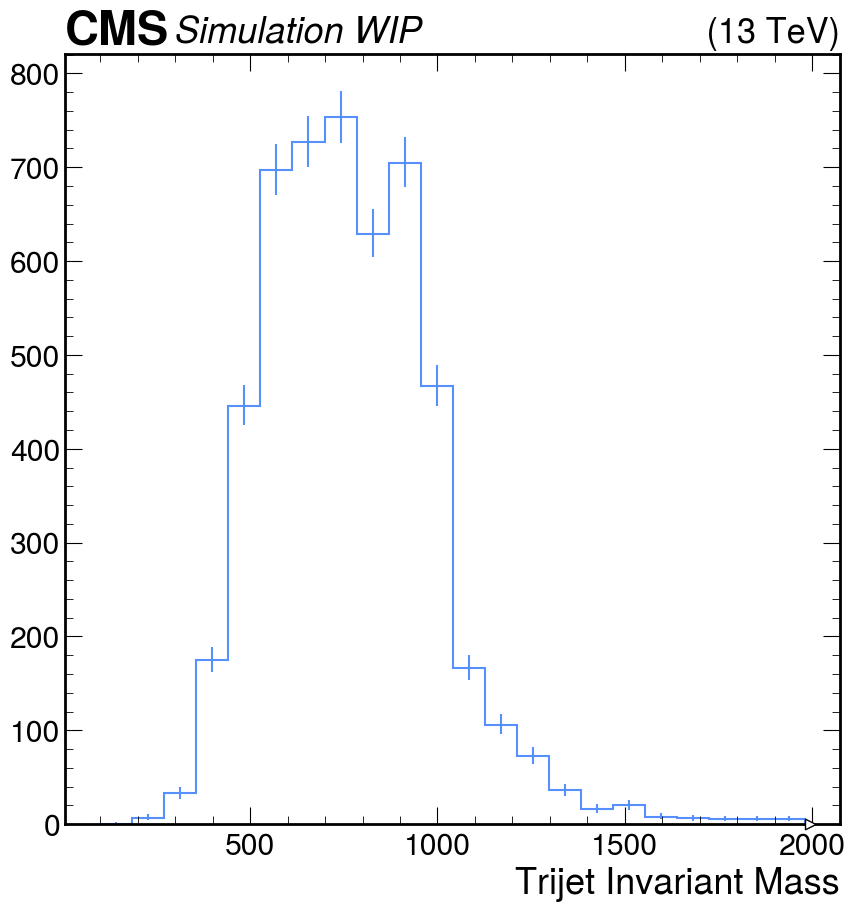

In [48]:
h[::45j].plot()
hep.cms.label(label="WIP")